#### Author: Frederik Alexander Ådlandsvik

##### Date: 20.09.2026

**AI statement**.

I have used AI tools for...

- translating handwritten notes to .md files
- making readable and informative plots
- debugging code for finding errors, artifacts and misbehaviour
- interpreting what each task wanted me to do, without giving me solutions, since it was somewhat unclear
- feedback for transitions in analytical derivations
- teaching me concepts, grounded in the Numerical Analysis book


Examples of prompts I used:

- "Create a simple printed table with the interpolation error for the respective values of n"
- "Debug to find out why the loss history is not being shown in the figure, let me implement the necessary changes"
- "Provide me with feedback, without giving me answers, for my derivation for this tightness bound for Chebyshev nodes, any claims must be grounded in the Numerical Analysis book"


I have actually noticed many instances where the AI-tools I used give misleading or wrong answers, in my opinion. For instance, working on task 1e) I wanted feedback for my approach, and it wanted me to not clamp the interval of nodes, so that they could go outside the interval, which I thought was wrong since it is a logical constraint, and it also wanted me to interpolate with RBF on Chebyshev and equidistant nodes, which I also thought was wrong. AI was good at helping with debugging, but not so much at interpreting. And there were also other use cases where it was misleading, perhaps since it was missing context or hallucinating, which made me more critical.


I have marked "generative usage" of AI with "[AI help]", where it single-handedly did the work.

### Task 1a)

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def lagrange_interp(nodes, vals, x_vals=[]):
    """Finds Lagrange interpolant and evaluates the function in x_vals."""
    # make sure scalars can be inputs
    x_vals = np.atleast_1d(np.asarray(x_vals, dtype=float))

    if len(np.unique(nodes)) != len(nodes):
        raise ValueError("nodes must be distinct")

    if len(x_vals) == 0:
        x_vals = nodes

    y_vals = np.zeros(len(x_vals))

    for j in range(len(nodes)):
        p_j = vals[j]

        for k in range(len(nodes)):
            if k == j: continue
            p_j *= (x_vals - nodes[k]) / (nodes[j] - nodes[k])

        y_vals += p_j

    return y_vals


def chebyshev_nodes_basic(n):
    x_vals = np.array([np.cos(np.pi/n * (k + 1/2)) for k in range(n)])

    return x_vals


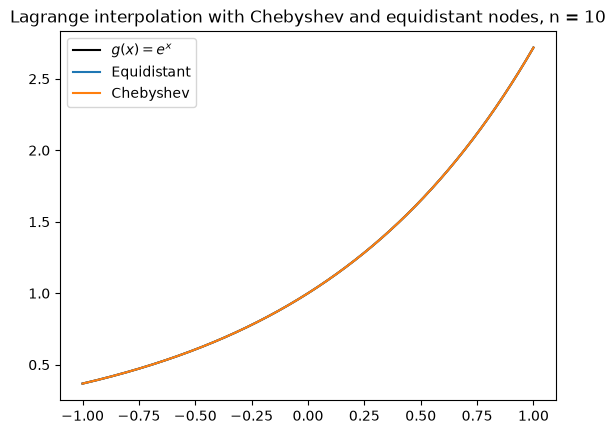

In [35]:
a = -1; b = 1; n = 10; N = 1000

# g \in C^{\infty}
def g(x):
    return np.exp(x)

e_nodes = np.linspace(a, b, n+1)
c_nodes = chebyshev_nodes_basic(n+1) 
x_vals = np.linspace(a, b, N)

y_equidistant = lagrange_interp(e_nodes, g(e_nodes), x_vals)
y_chebyshev = lagrange_interp(c_nodes, g(c_nodes), x_vals)

plt.title(f"Lagrange interpolation with Chebyshev and equidistant nodes, n = {n}")
plt.plot(x_vals, g(x_vals), label=r"$g(x) = e^x$", color="black")
plt.plot(x_vals, y_equidistant, label="Equidistant")
plt.plot(x_vals, y_chebyshev, label="Chebyshev")

plt.legend()
plt.show()

When for a function $g\in C^{\infty}[-1,1]$, we see that the interpolation polynomials above fit good with the function on the given interval, both for equidistant and Chebyshev nodes.

In [4]:
def chebyshev_nodes(a, b, n):
    x_vals = np.array([np.cos(np.pi/n * (k + 1/2)) for k in range(n)])
    x_thilde_vals = 1/2 * (a + b) + 1/2 * (b - a) * x_vals

    return x_thilde_vals
    

Interpolating Runge's function on $[-5,5]$ with $n=10$:

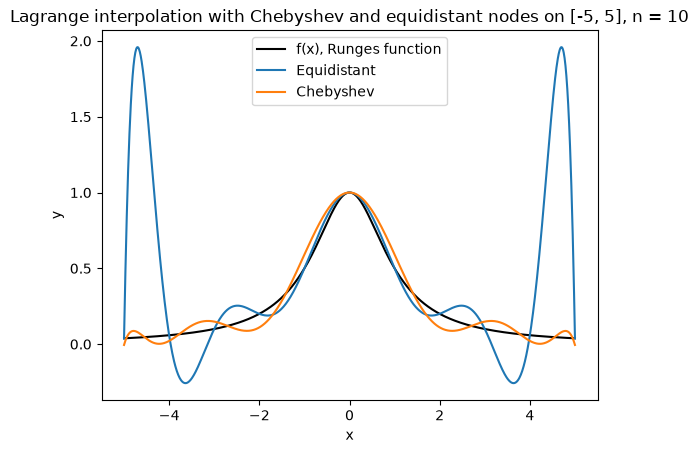

In [33]:
a = -5; b = 5; n = 10; N = 1000

# Runge's function
def f(x):
    return 1 / (1 + x**2)


fig, ax = plt.subplots(1,1)

x_equidistant = np.linspace(a, b, n+1)
x_chebyshev = chebyshev_nodes(a, b, n+1)

x_vals = np.linspace(x_equidistant[0], x_equidistant[-1], N+1)

y_equidistant = lagrange_interp(x_equidistant, f(x_equidistant), x_vals)
y_chebyshev = lagrange_interp(x_chebyshev, f(x_chebyshev), x_vals)

ax.plot(x_vals, f(x_vals), label="f(x), Runges function", color="black")
ax.plot(x_vals, y_equidistant, label="Equidistant")
ax.plot(x_vals, y_chebyshev, label="Chebyshev")

ax.set_title(f"Lagrange interpolation with Chebyshev and equidistant nodes on [{a}, {b}], n = {n}")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.legend()
plt.show()

**Prediction**. For increasing values of $n$ i predict that there will be increasing amounts of oscilliations for interpolation polynomial on equidistant nodes, considering the behaviour of the equidistant polynomial in the figure above. The Chebyshev polynomial gets weaker oscillations closer and closer when reaching the endpoints, due to a higher concentration of nodal points here.

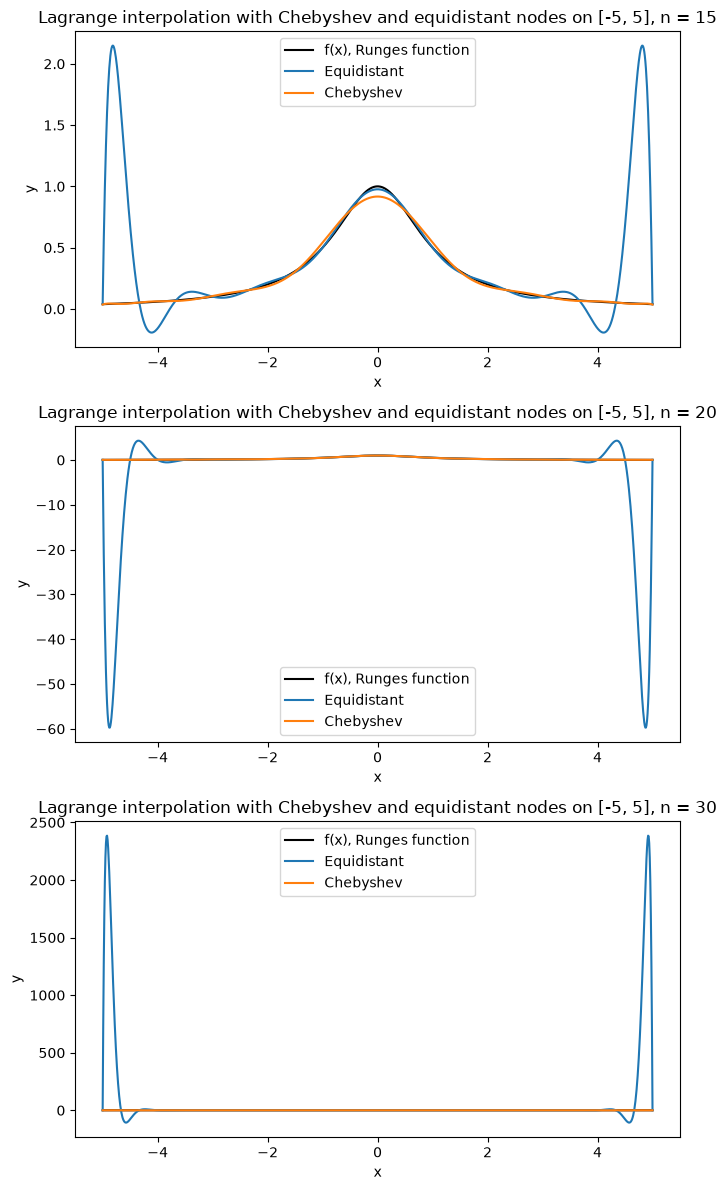

In [31]:
a = -5; b = 5; n = 10

fig, ax = plt.subplots(3, 1, figsize=(7, 12))

n_vals = [15, 20, 30]

# equidistant and Chebyshev nodes on [-5, 5]
for i in range(len(n_vals)):
    n_i = n_vals[i]
    x_equidistant = np.linspace(a, b, n_i+1)
    x_chebyshev = chebyshev_nodes(a, b, n_i+1)

    x_vals = np.linspace(a, b, N+1)

    y_equidistant = lagrange_interp(x_equidistant, f(x_equidistant), x_vals)
    y_chebyshev = lagrange_interp(x_chebyshev, f(x_chebyshev), x_vals)

    ax[i].plot(x_vals, f(x_vals), label="f(x), Runges function", color="black")
    ax[i].plot(x_vals, y_equidistant, label="Equidistant")
    ax[i].plot(x_vals, y_chebyshev, label="Chebyshev")

    ax[i].set_title(f"Lagrange interpolation with Chebyshev and equidistant nodes on [{a}, {b}], n = {n_i}")
    ax[i].set_xlabel("x")
    ax[i].set_ylabel("y")

    ax[i].legend()

plt.tight_layout()
plt.show()


In the three figures above we indeed observe that the interpolation polynomial on the equidistant nodes gets large oscillations near the endpoints of the interval, an example of the Runge phenomenon. Moreover, Faber's theorem tells us that this cannot be remedied by a better choice of nodes alone: for any configuration of interpolation nodes there exists a function $f \in C[a,b]$ for which the corresponding interpolation polynomials fail to converge uniformly to $f$.

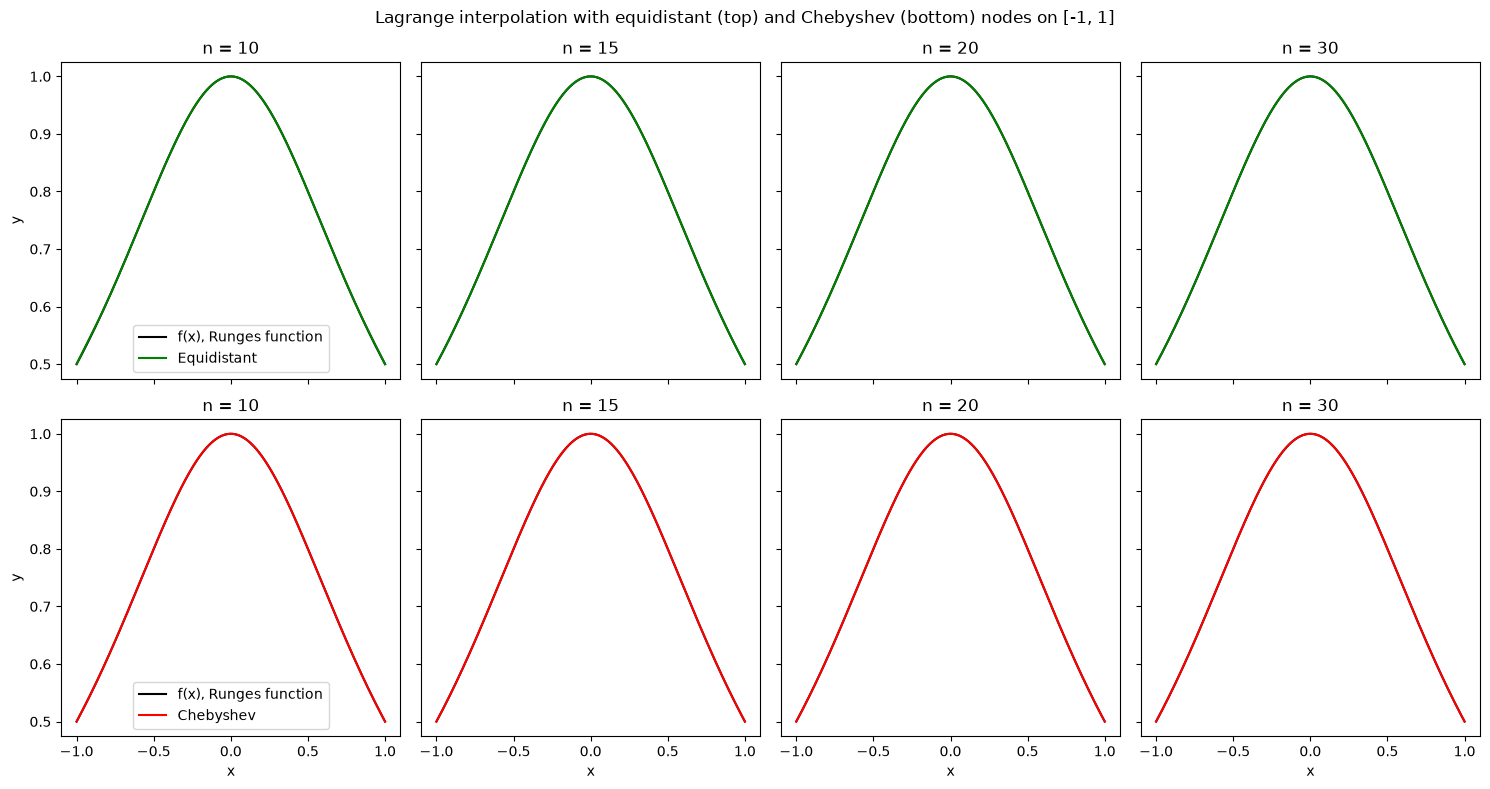

In [32]:
a = -1; b = 1;

n_vals = [10, 15, 20, 30]
fig, (ax1, ax2) = plt.subplots(2, 4, figsize=(15, 8), sharex=True, sharey=True)

# equidistant and Chebyshev nodes on [-1, 1]
for i in range(len(n_vals)):
    n_i = n_vals[i]
    x_equidistant = np.linspace(a, b, n_i+1)
    x_chebyshev = chebyshev_nodes(a, b, n_i+1)

    x_vals = np.linspace(a, b, N+1)

    y_equidistant = lagrange_interp(x_equidistant, f(x_equidistant), x_vals)
    y_chebyshev = lagrange_interp(x_chebyshev, f(x_chebyshev), x_vals)

    ax1[i].plot(x_vals, f(x_vals), label="f(x), Runges function", color="black")
    ax2[i].plot(x_vals, f(x_vals), label="f(x), Runges function", color="black")

    ax1[i].plot(x_vals, y_equidistant, label="Equidistant", color="green")
    ax2[i].plot(x_vals, y_chebyshev, label="Chebyshev", color="red")

    ax1[i].set_title(f"n = {n_i}")
    ax2[i].set_title(f"n = {n_i}")
    ax2[i].set_xlabel("x")

ax1[0].set_ylabel("y")
ax2[0].set_ylabel("y")
ax1[0].legend()
ax2[0].legend()

fig.suptitle(f"Lagrange interpolation with equidistant (top) and Chebyshev (bottom) nodes on [{a}, {b}]")
fig.tight_layout()



**Observation**. We observe that the interpolation polynomials on $[-1, 1]$ interpolates the Runge's function with little error, in contrast to the interval $[-5, 5]$, where the equidistant nodes gets increasingly larger oscillations closer to the endpoints. 

### Task 1b)

We are given two functions

$$
f(x) := \cos(2\pi x), \quad x \in [0, 1] \qquad \text{and} \qquad g(x) := e^{3x} \sin(2x), \quad x \in [0, \pi/4]
$$

We have that the interpolation error is given as

$$
y(x) - p_n(x) = \frac{y^{(n+1)}(\xi)}{(n+1)!} \pi_{n+1}(x), \quad \text{where} \quad \pi_{n+1}(x) := \prod_{i=0}^{n}(x - x_i) \quad \text{and} \quad \xi = \xi(x) \in [a,b]
$$

which gives

$$
||y(x) - p_n(x)||_{\infty} \le \frac{M_{n+1}}{(n+1)!} ||\pi_{n+1}(x)||_{\infty}, \quad \text{where} \quad M_{n+1} := \max_{\xi \in [a,b]} |y^{(n+1)}(\xi)|
$$

$f \in C^{\infty}[a,b]$ is not sufficient for convergence, as seen with Runge's function interpolated with equidistant nodes on $[-5,5]$.

In order for the interpolation polynomial to converge, $M_{n+1}$ needs to grow slower than $||\pi_{n+1}(x)||$ grows for $n \to \infty$.

For the equidistant nodes on $[a,b]$ we can claim that

$$
h = (b - a)/n \Longrightarrow ||\pi_{n+1}(x)|| \le \frac{1}{4} n! h^{n+1},
$$

and the proof for this bound follows:

Fix $x \in [a,b]$ and $x \in [x_j,x_{j+1}]$ for $0 \le j \le n-1$. With $t = x - x_j \in [0,h]$ the two nearest factors give $|x-x_j||x-x_{j+1}| = t(h-t) \le h^2/4$, since $t = h/2$ is the maximum.

All other nodes lie outside $[x_j,x_{j+1}]$, so their distance to $x$ is at most the distance to the far endpoint of that subinterval. $|x-x_i| \le (j+1-i)h$ for $i \le j-1$, and $|x-x_i| \le (i-j)h$ for $i \ge j+2$. Multiplying these $n-1$ factors gives $h^{j}(j+1)! \cdot h^{n-j-1}(n-j)! = h^{n-1}(j+1)!(n-j)!$, where empty products are $1$. Hence $|\pi_{n+1}(x)| \le \frac{h^{n+1}}{4}(j+1)!(n-j)!$.

Finally, with $k = j+1 \in \{1,\dots,n\}$ we have $(j+1)!(n-j)! = k!(n+1-k)! = (n+1)!/\binom{n+1}{k}$, and since binomial coefficients in a row are smallest at the ends, $\binom{n+1}{k} \ge n+1$. So $(j+1)!(n-j)! \le n!$, and

$$
|\pi_{n+1}(x)| \le \tfrac14 n!\,h^{n+1}. \qquad \blacksquare
$$

And for Chebyshev nodes on $[a,b]$

$$
||\pi_{n+1}(x)|| = 2 ((b-a)/4)^{n+1},
$$

which has the following proof:

Let $x_i = \frac{a+b}{2} + \frac{b-a}{2}\cos\!\left(\frac{(2i+1)\pi}{2n+2}\right)$, $i = 0,\dots,n$, be the Chebyshev nodes on $[a,b]$, and $\pi_{n+1}(x) = \prod_{i=0}^{n}(x-x_i)$.

Let then $d_i = \cos\frac{(2i+1)\pi}{2n+2}$ to the $x_i$. This gives $x - x_i = \frac{b-a}{2}(d-d_i)$, so $\pi_{n+1}(x) = \left(\frac{b-a}{2}\right)^{n+1}\prod_{i=0}^{n}(d-d_i)$.

We know that the $d_i$ are the roots of the Chebyshev polynomial $T_{n+1}(d) = \cos((n+1)\arccos d)$, with leading coefficients $2^{n}$. For such a monic polynomial, we can write

$$
\prod_{i=0}^{n}(d-d_i) = 2^{-n}T_{n+1}(d),
$$

Since $T_{n+1}$ is a cosine function, it never exceeds $1$ in absolute value, and $T_{n+1}(1) = 1$, so the maximum of the product on $[-1,1]$ is exactly $2^{-n}$.

Therefore

$$
\|\pi_{n+1}\|_\infty = \left(\frac{b-a}{2}\right)^{n+1}2^{-n} = \frac{(b-a)^{n+1}}{2^{2n+1}} = 2\left(\frac{b-a}{4}\right)^{n+1}. \qquad \blacksquare
$$

By theorem 8.7 in *An introduction to Numerical Analysis* (Süli and Mayers) this is the smallest max norm any monic polynomial of degree $n+1$ can have on $[a,b]$, and this is therefore the best choice of nodes.

For the factor $M_n$ we can show that for $f$ it follows that

$$
f^{(k)}(x) = (2\pi)^k \cos\!\left(2\pi x + k\pi/2\right), \qquad k \ge 0,
$$

which follows by induction: the formula holds for $k = 0$, and differentiating the right-hand side gives $-(2\pi)^{k+1}\sin(2\pi x + k\pi/2) = (2\pi)^{k+1}\cos(2\pi x + (k+1)\pi/2)$. Hence

$$
|f^{(n+1)}(x)| \le (2\pi)^{n+1} = M_{n+1},
$$

and since the cosine is bounded by $\pm 1$ on $[0,1]$ for every $n$, $M_{n+1} = \max_{[0,1]}|f^{(n+1)}|$.

For $g$ we similarly find that for $g(x) = \operatorname{Im}\!\left(e^{(3+2i)x}\right)$, we get

$$
g^{(k)}(x) = \operatorname{Im}\!\left((3+2i)^k e^{(3+2i)x}\right), \qquad k \ge 0.
$$

Therefore, on $[0,\pi/4]$,

$$
|g^{(n+1)}(x)|
\;\le\; |3+2i|^{\,n+1}\left|e^{(3+2i)x}\right|
\;=\; 13^{(n+1)/2}e^{3x}
\;\le\; 13^{(n+1)/2}e^{3\pi/4} = M_{n+1}.
$$

Here both $|\operatorname{Im}(z)| \le |z|$ and $e^{3x} \le e^{3\pi/4}$ are used, and the two are not sharp at the same point. This approximation will affect the tightness, but more on that later.

We find that $M_{n+1} \le K \cdot C^{n+1}$, where $K$ and $C$ are positive constants independent of $n$, so the interpolation polynomial converges as $n \to \infty$.

This gives for equidistant nodes in max norm

$$
\begin{aligned}
    ||f - p_n||_{\infty} &\le \frac{(2\pi)^{n+1}}{(n+1)!} \cdot \frac{1}{4} n! h^{n+1} = \frac{1}{4(n+1)} (2\pi h)^{n+1} = \frac{1}{4(n+1)} \left(\frac{2\pi(b-a)}{n}\right)^{n+1}, \\[2mm]
    ||g - p_n||_{\infty} &\le \frac{13^{(n+1)/2} e^{3\pi/4}}{(n+1)!} \cdot \frac{1}{4} n! h^{n+1} = \frac{e^{3\pi/4}}{4(n+1)} (13^{1/2} h)^{n+1} = \frac{e^{3\pi/4}}{4(n+1)} \left(\frac{13^{1/2}(b-a)}{n}\right)^{n+1}.
\end{aligned}
$$

For the Chebyshev nodes in max norm we find

$$
\begin{aligned}
    ||f - p_n||_{\infty} &\le \frac{(2\pi)^{n+1}}{(n+1)!} \cdot 2 ((b-a)/4)^{n+1} = \frac{2}{(n+1)!} \left(\frac{\pi (b-a)}{2}\right)^{n+1} = \frac{2}{(n+1)!} \left(\frac{\pi}{2}\right)^{n+1}, \\[2mm]
    ||g - p_n||_{\infty} &\le \frac{13^{(n+1)/2} e^{3\pi/4}}{(n+1)!} \cdot 2 ((b-a)/4)^{n+1} = \frac{2e^{3\pi/4}}{(n+1)!} \left(\frac{13^{1/2}(b-a)}{4}\right)^{n+1} = \frac{2e^{3\pi/4}}{(n+1)!} \left(\frac{13^{1/2}\pi}{16}\right)^{n+1}.
\end{aligned}
$$

For equidistant nodes $h = (b-a)/n$, so

$$
\frac{M_{n+1}}{(n+1)!}||\pi_{n+1}||_{\infty} \le \frac{K C^{n+1}}{(n+1)!}\cdot\frac{1}{4}n!\,h^{n+1}
= \frac{K}{4(n+1)}\left(\frac{C(b-a)}{n}\right)^{n+1} \longrightarrow 0,
$$

since $C(b-a)/n \le 1/2$ for $n \ge 2C(b-a)$. The factor $n!$ cancels against $(n+1)!$, so the convergence comes from $h \to 0$. For Chebyshev nodes

$$
\frac{M_{n+1}}{(n+1)!}||\pi_{n+1}||_{\infty} \le \frac{K C^{n+1}}{(n+1)!}\cdot 2\left(\frac{b-a}{4}\right)^{n+1}
= \frac{2K}{(n+1)!}\left(\frac{C(b-a)}{4}\right)^{n+1} \longrightarrow 0,
$$

since $r^{m}/m! \to 0$ for every fixed $r > 0$.

For Runge's function $r(x) := 1/(1+x^2)$ on $[-5,5]$ the geometric series gives

$$
r(x) = \sum_{k=0}^{\infty}(-1)^k x^{2k}, \quad |x| < 1 \qquad \Longrightarrow \qquad r^{(2k)}(0) = (-1)^k (2k)!,
$$

so for odd $n$ we have $M_{n+1} \ge |r^{(n+1)}(0)| = (n+1)!$, and the factorial in the error formula disappears. Evaluating $\pi_{n+1}$ at the midpoint of the first subinterval, $x^* := a + h/2$ with $h = 10/n$,

$$
||\pi_{n+1}||_{\infty} \ge |\pi_{n+1}(x^*)| = h^{n+1}\prod_{i=0}^{n}\left|\tfrac{1}{2} - i\right|
= \frac{(2n-1)!!}{2^{n+1}} h^{n+1} \sim \frac{10}{\sqrt{2}\,n}\left(\frac{10}{e}\right)^{n} \qquad [\text{Stirling's approx}],
$$

so that

$$
\frac{M_{n+1}}{(n+1)!}||\pi_{n+1}||_{\infty} \ge ||\pi_{n+1}||_{\infty} \longrightarrow \infty, \quad n \to \infty.
$$

Here $M_{n+1}$ grows factorially rather than geometrically, which is exactly what separates $r$ from $f$ and $g$.

We use the ML inequality to find a relationship between $2$ norm and the max norm:

$$
||f - p_n||_2^2 = \int_a^b (f - p_n)^2 \, dx \overset{ML}{\le} (b-a) \max_{x \in [a,b]} (f-p_n)^2
$$

$$
\Longrightarrow \quad ||f - p_n||_2 \le \sqrt{b-a} \max_{x \in [a,b]} |f - p_n| = \sqrt{b-a} \, ||f - p_n||_{\infty}
$$

We see that the 2 norm for functions is bounded by the max norm, which will be used in the discrete case to comment on the bounds.

Below follows the implementation of the code, using the derived error bounds.

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt


def factorial(k):
    return np.array([math.factorial(int(j)) for j in np.atleast_1d(k)], dtype=float)

def two_norm_error(f, nodes, y_vals):
    """Discrete L2 error between f and the approximation y_vals sampled on nodes."""
    a, b = nodes[0], nodes[-1]
    N = len(nodes)

    return np.sqrt((b - a)/N) * np.sqrt(np.sum((f(nodes) - y_vals)**2))

def max_norm_error(f, nodes, y_vals):
    """Discrete max error between f and the approximation y_vals sampled on nodes."""
    return np.max(np.abs(f(nodes) - y_vals))


def lagrange_error(f, n, a, b, N, chebyshev=True):
    """Sample the degree-n Lagrange interpolant of f on a grid of N points."""
    if chebyshev:
        interp_nodes = chebyshev_nodes(a, b, n+1)
    else:
        interp_nodes = np.linspace(a, b, n+1)

    x_vals = np.linspace(a, b, N)
    y_vals = lagrange_interp(interp_nodes, f(interp_nodes), x_vals)

    return x_vals, y_vals


def error_bound_f(a, b, n, chebyshev=False, norm="max"):
    """Analytical error bound for f, for both Chebyshev and equidistant nodes"""
    max_bound = 1/(4*(n+1)) * ((2*np.pi*(b-a))/n)**(n+1) # equidistant bound

    if chebyshev == True:
        max_bound = 2/factorial(n+1) * (np.pi/2)**(n+1) # Chebyshev bound

    if norm == "two":
        max_bound *= np.sqrt(b-a)

    return max_bound


def error_bound_g(a, b, n, chebyshev=False, norm="max"):
    """Analytical error bound for g, for both Chebyshev and equidistant nodes"""
    max_bound = np.exp(3*np.pi/4)/(4*(n+1)) * (np.sqrt(13)*(b-a)/n)**(n+1) # equidistant bound

    if chebyshev == True:
        max_bound = 2*np.exp(3*np.pi/4)/factorial(n+1) * (np.sqrt(13)*(b-a)/4)**(n+1) # Chebyshev bound

    if norm == "two":
        max_bound *= np.sqrt(b-a)

    return max_bound


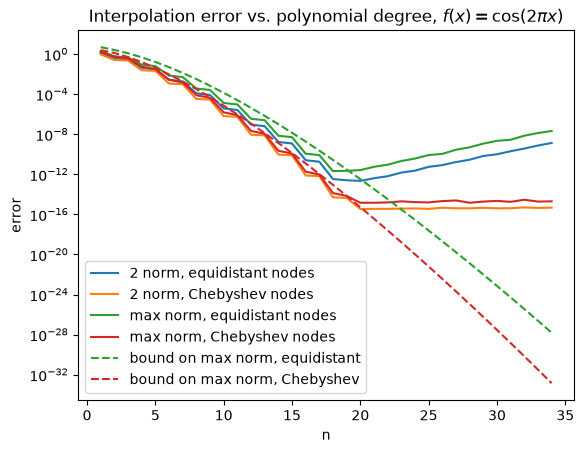

In [9]:
# parameters for func f
a_f = 0; b_f = 1; n_max = 35

# parameters for func g
a_g = 0; b_g = np.pi/4; n_max = 35

n_vals = np.arange(1, n_max)

def f(x):
    return np.cos(2*np.pi*x)

def g(x):
    return np.exp(3*x) * np.sin(2*x)

# nodes for interpolation of f
e_nodes_f = [lagrange_error(f, k, a_f, b_f, 100*n_max, chebyshev=False) for k in n_vals]
c_nodes_f = [lagrange_error(f, k, a_f, b_f, 100*n_max, chebyshev=True) for k in n_vals]

# nodes for interpolation of g
e_nodes_g = [lagrange_error(g, k, a_g, b_g, 100*n_max, chebyshev=False) for k in n_vals]
c_nodes_g = [lagrange_error(g, k, a_g, b_g, 100*n_max, chebyshev=True) for k in n_vals]

# 2 norm and max norm error for interpolation of f
error_2_norm_equidistant_f = np.array([two_norm_error(f, x, y) for x, y in e_nodes_f])
error_2_norm_chebyshev_f = np.array([two_norm_error(f, x, y) for x, y in c_nodes_f])
error_max_norm_equidistant_f = np.array([max_norm_error(f, x, y) for x, y in e_nodes_f])
error_max_norm_chebyshev_f = np.array([max_norm_error(f, x, y) for x, y in c_nodes_f])

# 2 norm and max norm error for interpolation of g
error_2_norm_equidistant_g = np.array([two_norm_error(g, x, y) for x, y in e_nodes_g])
error_2_norm_chebyshev_g = np.array([two_norm_error(g, x, y) for x, y in c_nodes_g])
error_max_norm_equidistant_g = np.array([max_norm_error(g, x, y) for x, y in e_nodes_g])
error_max_norm_chebyshev_g = np.array([max_norm_error(g, x, y) for x, y in c_nodes_g])

# plotting for interpolation of f
plt.semilogy(n_vals, error_2_norm_equidistant_f, label="2 norm, equidistant nodes")
plt.semilogy(n_vals, error_2_norm_chebyshev_f, label="2 norm, Chebyshev nodes")
plt.semilogy(n_vals, error_max_norm_equidistant_f, label="max norm, equidistant nodes")
plt.semilogy(n_vals, error_max_norm_chebyshev_f, label="max norm, Chebyshev nodes")

plt.semilogy(n_vals, error_bound_f(a_f, b_f, n_vals, chebyshev=False), "C2--", label="bound on max norm, equidistant")
plt.semilogy(n_vals, error_bound_f(a_f, b_f, n_vals, chebyshev=True), "C3--", label="bound on max norm, Chebyshev")

plt.xlabel("n")
plt.ylabel("error")
plt.title(r"Interpolation error vs. polynomial degree, $f(x) = \cos(2\pi x)$")
plt.legend()
plt.show()

In the figure above we see that the equidistant and Chebyshev error is bounded by the bounds found earlier, since the 2 norm is bounded by the max norm, only the max norm is displayed here. The Chebyshev error reaches a floor of $\sim 10^{-14}$, at the lower bound for machine precision. Interestingly, the equidistant error increases after $n\approx 20$, which can be linked to Runge's phenomenon, where the large oscillations cause an increasing error for increasing $n$. 

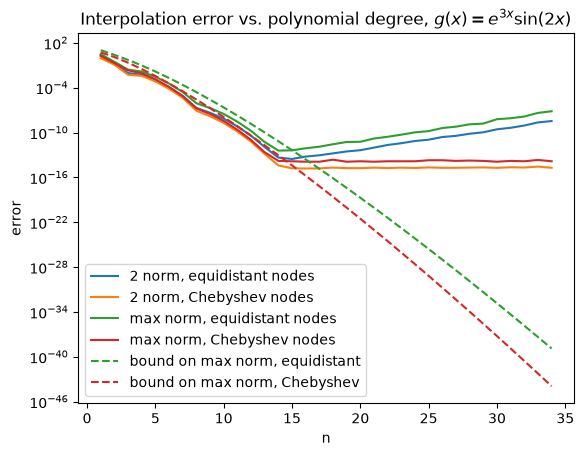

In [10]:
# plotting for interpolation of g
plt.semilogy(n_vals, error_2_norm_equidistant_g, label="2 norm, equidistant nodes")
plt.semilogy(n_vals, error_2_norm_chebyshev_g, label="2 norm, Chebyshev nodes")
plt.semilogy(n_vals, error_max_norm_equidistant_g, label="max norm, equidistant nodes")
plt.semilogy(n_vals, error_max_norm_chebyshev_g, label="max norm, Chebyshev nodes")

plt.semilogy(n_vals, error_bound_g(a_g, b_g, n_vals, chebyshev=False), "C2--", label="bound on max norm, equidistant")
plt.semilogy(n_vals, error_bound_g(a_g, b_g, n_vals, chebyshev=True), "C3--", label="bound on max norm, Chebyshev")

plt.xlabel("n")
plt.ylabel("error")
plt.title(r"Interpolation error vs. polynomial degree, $g(x) = e^{3x} \sin(2x)$")
plt.legend()
plt.show()

In the figure above we see that the equidistant and Chebyshev error is bounded by the bounds found earlier, since the 2 norm is bounded by the max norm, only the max norm is displayed here. The Chebyshev error reaches again a floor of $\sim 10^{-14}$, at the lower bound for machine precision. Interestingly, the equidistant error increases after $n\approx 15$, which can be linked to Runge's phenomenon, where the large oscillations cause an increasing error for increasing $n$. 

#### How tight is the bound?

The factor $\max_{[a,b]}|f^{(n+1)}|$ does not depend on the choice of nodes, so $\pi_{n+1}$ is what varies.

For the Chebyshev nodes

$$
\prod_{i=0}^{n}(x - x_i) = \left(\frac{b-a}{2}\right)^{\! n+1} 2^{-n}\,T_{n+1}(d),
\qquad d = \frac{2x - a - b}{b - a},
$$

and $T_{n+1}$ has the values $\pm 1$ at $n+2$ points of $[-1,1]$, so the product oscillates between $\pm 2\left((b-a)/4\right)^{n+1}$ across the whole interval. For equidistant nodes the product is by contrast extremely small in the middle of the interval and largest in the two outermost subintervals.

The reason there is a gap is that in the error formula for the interpolation polynomial there is the factor

$$
f^{(n+1)}(\xi(x)) \prod_i (x - x_i),
$$

and the bound uses the maximum of both the factors, but they don't have to have their maxima at the same points.

The Chebyshev nodes minimize $\max_x |\prod_i (x-x_i)|$, and one can compare the factor $|\prod_i (x - x_i)|$ for equidistant and Chebyshev nodes and see that

$$
\begin{aligned}
    \text{Equidistant:} \quad &\left|\prod\right|_{\text{eq}} \le n! \, h^{n+1} \sim \sqrt{2\pi/n} \; e^{-n} (b-a)^{n+1} \qquad [\text{Stirling's approx}] \\
    \text{Chebyshev:} \quad &\left|\prod\right|_{\text{cheb}} \le 2 ((b-a)/4)^{n+1}
\end{aligned}
$$

$$
\Longrightarrow \quad \frac{\left|\prod\right|_{\text{eq}}}{\left|\prod\right|_{\text{cheb}}} \sim (4/e)^n \simeq 1{,}47^n
$$

What the comparison shows is that the node product for equidistant nodes exceeds the Chebyshev one by a factor growing like $1.47^{\,n}$, making the equidistant bound less and less tight for increasing $n$.

#### Numerical estimates for the tightness

In [ ]:
# tightness numerical approximation for func f
def pi_max(nodes, x):
    """max_x |prod_i (x - x_i)|"""
    return np.max(np.abs(np.prod(np.expand_dims(x, axis=1) - np.expand_dims(nodes, axis=0), axis=1)))

x_eval = np.linspace(a_f, b_f, 100*n_max)

# numerical table with bound estimations for equidistant and Chebyshev nodes [AI help] 
for cheb, name in [(False, "Equidistant"), (True, "Chebyshev")]:
    print(f"\n{name} nodes, f(x) = cos(2*pi*x)")
    print(f"{'n':>3} {'error':>10} {'max|PI|':>10} {'est|PI|':>10} {'est/max':>8} {'bound':>10} {'bound/err':>10}")

    for n in [4, 6, 8, 10, 12, 16]:
        nodes = chebyshev_nodes(a_f, b_f, n+1) if cheb else np.linspace(a_f, b_f, n+1)

        error_est = max_norm_error(f, *lagrange_error(f, n, a_f, b_f, 100*n_max, chebyshev=cheb))
        deriv_term = (2*np.pi)**(n+1) / factorial(n+1)[0] # M_{n+1}/(n+1)!
        PI = pi_max(nodes, x_eval) # measured product
        PI_est = 2*((b_f-a_f)/4)**(n+1) if cheb else factorial(n)[0]*((b_f-a_f)/n)**(n+1)/4 # analytical product
        bound = deriv_term*PI_est

        print(f"{n:>3} {error_est:10.2e} {PI:10.2e} {PI_est:10.2e} {PI_est/PI:8.2f} {bound:10.2e} {bound/error_est:10.1f}")


Equidistant nodes, f(x) = cos(2*pi*x)
  n      error    max|PI|    est|PI|  est/max      bound  bound/err
  4   8.88e-02   3.55e-03   5.86e-03     1.65   4.78e-01        5.4
  6   7.12e-03   3.42e-04   6.43e-04     1.88   4.93e-02        6.9
  8   3.66e-04   3.67e-05   7.51e-05     2.04   3.16e-03        8.6
 10   1.31e-05   4.17e-06   9.07e-06     2.18   1.37e-04       10.4
 12   3.48e-07   4.89e-07   1.12e-06     2.29   4.28e-06       12.3
 16   1.14e-10   7.19e-09   1.77e-08     2.46   1.85e-09       16.2

Chebyshev nodes, f(x) = cos(2*pi*x)
  n      error    max|PI|    est|PI|  est/max      bound  bound/err
  4   5.55e-02   1.95e-03   1.95e-03     1.00   1.59e-01        2.9
  6   2.71e-03   1.22e-04   1.22e-04     1.00   9.36e-03        3.5
  8   7.88e-05   7.63e-06   7.63e-06     1.00   3.21e-04        4.1
 10   1.54e-06   4.77e-07   4.77e-07     1.00   7.20e-06        4.7
 12   2.14e-08   2.98e-08   2.98e-08     1.00   1.14e-07        5.3
 16   1.85e-12   1.16e-10   1.16e-10    

**Equidistant nodes**: As $n$ increases, the upper bound for $|\prod|$ (est|PI|) gets comparatively larger than what we observe for $|\prod|$ (max|PI|), and we also observe this for the bound relatively compared to the error, meaning that the analytical bound gets less and less tight, due to the derivative term having maxima not alligned with $|\prod|$, and the maxima of both become further apart and the product overestimates by a growing factor.


**Chebyshev nodes**: As expected, $|\prod| = |\prod|_{\text{max}}$ for all $n$, so our upper bound is also what we observe. Here the bound also decays slower than the error, meaning that the analytical bound gets less and less tight, for the same reason as with the equidistant nodes.

### Task 1c)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter

def piecewise_lagrange_interp(outer_nodes, f, n, x):
    """Evaluating the piecewise interpolation polynomial in x."""
    y = np.empty_like(x, dtype=float)

    for i in range(len(outer_nodes) - 1):

        # mask to find subinterval
        if i == len(outer_nodes) - 2:
            mask = (x >= outer_nodes[i]) & (x <= outer_nodes[i+1]) # last includes b
        else:
            mask = (x >= outer_nodes[i]) & (x < outer_nodes[i+1])

        if not mask.any():
            continue

        nodes = np.linspace(outer_nodes[i], outer_nodes[i+1], n+1)
        y[mask] = lagrange_interp(nodes, f(nodes), x[mask])

    return y


# one of the test functions from 1b)
def f(x):
    return np.cos(2*np.pi*x)


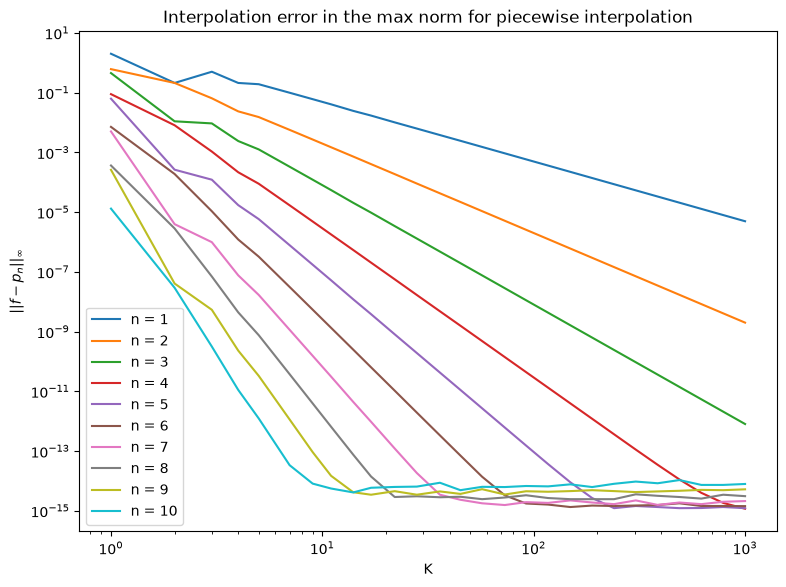

In [13]:
a, b = 0, 1
n_max_pw = 10; n_max_global = 100; # pw = piecewise and global = not piecewise

K_vals = np.unique(np.logspace(0, 3, 30).round().astype(int))

fig, ax = plt.subplots(figsize=(9, 6.5))

for n in range(1, n_max_pw+1):
    error = []

    for K in K_vals:
        outer_nodes = np.linspace(a, b, K+1)
        x_eval_pw = np.linspace(a, b, 100*K + 1) # 100 points per subinterval
        y_vals = piecewise_lagrange_interp(outer_nodes, f, n, x_eval_pw)
        error.append(max_norm_error(f, x_eval_pw, y_vals))

    ax.set_title("Interpolation error in the max norm for piecewise interpolation")
    ax.loglog(K_vals, error, label=f"n = {n}")

ax.set_xlabel("K")
ax.set_ylabel(r"$||f-p_n||_{\infty}$")

ax.legend()
plt.show()

The figure above shows a loglog plot showing that the interpolation error decays more rapidly for higher values of $n$, in other words, that more nodes in each subinterval gives more accurate approximation in max norm. We specially see that the the error decays linearly, and it reaches a floor at around $10^{-14}$, which is approximately the accuracy for floating numbers in NumPy.

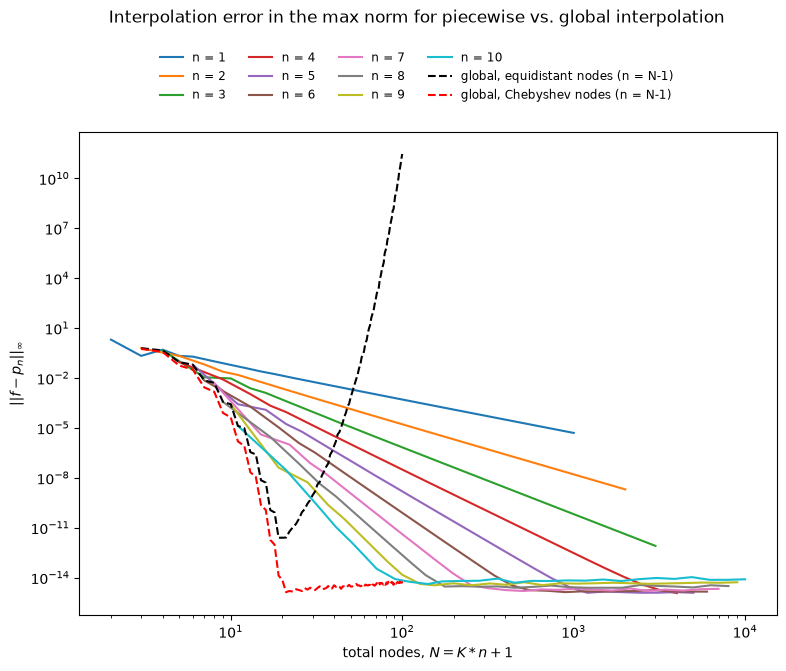

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))

for n in range(1, n_max_pw+1):
    total_nodes_piecewise, error = [], []

    for K in K_vals:
        outer_nodes = np.linspace(a, b, K+1)
        x_eval_pw = np.linspace(a, b, 100*K + 1) # 100 points per subinterval
        y_vals = piecewise_lagrange_interp(outer_nodes, f, n, x_eval_pw)

        e = max_norm_error(f, x_eval_pw, y_vals)
        total_nodes_piecewise.append(K*n + 1); error.append(e)

    ax.loglog(total_nodes_piecewise, error, label=f"n = {n}")


total_nodes_global = []
error_equidistant = []
error_chebyshev = []

x_eval_global = np.linspace(a, b, 100*n_max_global + 1)

for n_global in range(2, 100):
    nodes_equidistant = np.linspace(a, b, n_global+1)
    nodes_chebyshev = chebyshev_nodes(a, b, n_global+1)

    y_equidistant = lagrange_interp(nodes_equidistant, f(nodes_equidistant), x_eval_global)
    y_chebyshev = lagrange_interp(nodes_chebyshev, f(nodes_chebyshev), x_eval_global)

    total_nodes_global.append(n_global + 1)
    error_equidistant.append(max_norm_error(f, x_eval_global, y_equidistant))
    error_chebyshev.append(max_norm_error(f, x_eval_global, y_chebyshev))


ax.loglog(total_nodes_global, error_equidistant, label="global, equidistant nodes (n = N-1)", color="k", linestyle="--")
ax.loglog(total_nodes_global, error_chebyshev, label="global, Chebyshev nodes (n = N-1)", color="r", linestyle="--")

ax.set_xlabel(r"total nodes, $N = K*n + 1$")
ax.set_ylabel(r"$||f-p_n||_{\infty}$")

# custom figure formatting [AI help]
fig.subplots_adjust(top=0.80)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=4, fontsize="small", frameon=False)
fig.suptitle("Interpolation error in the max norm for piecewise vs. global interpolation", y=0.975)
plt.show()

In the figure aboce we observe that the max norm error for global interpolation polynomials, both on equidistant and Chebyshev nodes, decrease more quickly for low values of $n$, but similarly for 1b), the error for the interpolants on equidistant nodes start increasing after $n\approx 20$, and the interpolants on Chebychev nodes reach a floor of $\approx 10^{-14}$, due to machine precision, and start increasing after that. I'll try to explain some of these observations:



The test function $f(x)=\cos(2\pi x)$ on $[0,1]$, where a $n$ = degree per subinterval, $K$ = number of subintervals, $N = Kn+1$ = total number of nodes (for global interpolation: $N = n+1$), $M$ = number of points at which the interpolant is evaluated.

The error formula is the same for both methods: 

$$f(x) - p(x) = \frac{f^{(n+1)}(\xi)}{(n+1)!}\prod_{i=0}^{n}(x-x_i).$$


**Piecewise, $n$ fixed.** 

Here, $\max|f^{(n+1)}| = (2\pi)^{n+1}$ is a constant, and $\max|\prod| \le n!,h^{n+1}/4$ on each subinterval with $h=(b-a)/K$. This gives

$$|f-p\|_\infty \le \frac{(2\pi h)^{n+1}}{4(n+1)} \sim N^{-(n+1)},$$

a straight line with slope $-(n+1)$, as seen for the lines in the log–log plot in the figure above.

**Global, $n = N-1$ not fixed.** 

The numerator $(2\pi)^{n+1}$ grows geometrically, but the denominator $(n+1)!$ grows factorially, and for Chebyshev nodes, $\max|\prod| = 2\cdot 4^{-(n+1)}$ on $[0,1]$:

$$\|f-p\|_\infty \le \frac{2(\pi/2)^{n+1}}{(n+1)!}.$$

Piecewise interpolation with fixed $n$ uses only $n+1$ derivatives of $f$, regardless of how many nodes, and then it doesn't matter that $\cos$ has all derivatives bounded. Global interpolation of degree $N-1$ uses the $N$-th derivative. The error decays faster than any power of $N$.


#### **Analytical runtime analysis**
 
We count FLOPs for evaluating the interpolant in $M$ points. The Lagrange interpolant through the nodes $x_0,\dots,x_n$ is
 
$$p(x)=\sum_{j=0}^{n} y_j \prod_{k\neq j}\frac{x-x_k}{x_j-x_k},$$
 
which we compute with a double loop: an outer loop over $j$ and an inner loop over $k \neq j$.
 
**Global interpolation.** Here we use $N$ nodes on the whole interval, so $n+1 = N$ and both loops together have $N(N-1)$ iterations. In each iteration $x - x_k$ and $x_j - x_k$ is computed, divide them, and multiply the result into the product. That is 4 FLOPs. The outer loop only adds $\mathcal{O}(N)$, so per point we get
 
$$4N(N-1) + \mathcal{O}(N) \approx 4N^2 \text{ FLOPs}.$$
 
For $M$ points this is about $4N^2M$ FLOPs, i.e. $\mathcal{O}(N^2M)$.
 
**Piecewise interpolation.** Now the interval is split into $K$ subintervals, and on each subinterval we interpolate with degree $n$, here with $m = n+1$ nodes. A point is evaluated with the interpolant on its own subinterval, so this works like the global case with $m$ nodes instead of $N$.
 
The difference is that the denominator $x_j - x_k$ does not depend on $x$, so we compute it once for each pair $(j,k)$ instead of once for each point. That is $m(m-1)$ FLOPs per subinterval, so $Km(m-1)$ in total. This does not grow with $M$, and it is small compared to the cost below as long as $K \ll M$, so we leave it out.
 
Per point we then have 3 FLOPs per iteration in both loops together (one subtraction, one division and one multiplication) and $m$ FLOPs from the outer loop:
 
$$3m(m-1) + m = 3m^2 - 2m \approx 3(n+1)^2 \text{ FLOPs}.$$
 
Each point lies in exactly one subinterval. If subinterval $k$ contains $M_k$ points, then $\sum_{k=1}^{K} M_k = M$, and the total cost is
 
$$\sum_{k=1}^{K} (3m^2 - 2m) M_k = (3m^2 - 2m) \sum_{k=1}^{K} M_k = (3m^2 - 2m) M .$$
 
So evaluating the piecewise interpolant is $\mathcal{O}((n+1)^2 M)$, and this does not depend on $K$. More subintervals just means fewer points in each one.
 
In `piecewise_lagrange_interp` I find the points belonging to each subinterval by forming a boolean mask over the whole evaluation array. This costs $\mathcal{O}(M)$ and is done once per subinterval, so it adds $\Theta(KM)$ in total. My total runtime therefore becomes
 
$$\mathcal{O}\big((n+1)^2 M + KM\big),$$
 
so the measured runtime grows linearly in $K$ because of the mask.
 


#### **Numerical runtime analysis**


In [15]:
def piecewise_perf(f, a, b, n, K, x_eval, runs=10):
    """Measures the performance of piecewise interpolation of f on [a, b], given n and K"""

    best_time = np.inf

    # find the best time over multiple runs given same params 
    for _ in range(runs):
        start_time = perf_counter()
        outer_nodes = np.linspace(a, b, K+1)
        y_vals = piecewise_lagrange_interp(outer_nodes, f, n, x_eval)
        end_time = perf_counter()

        best_time = min(best_time, end_time - start_time)

    return best_time


def global_perf(f, a, b, n, x_eval, runs=10):
    """Measures the performance of global interpolation of f on [a, b], given n"""

    c_nodes = chebyshev_nodes(a, b, n+1)
    best_time = np.inf

    # find the best time over multiple runs given same params 
    for _ in range(runs):
        start_time = perf_counter()
        y_vals = lagrange_interp(c_nodes, f(c_nodes), x_eval)
        end_time = perf_counter()

        best_time = min(best_time, end_time - start_time)

    return best_time

In [16]:
# performance at a fixed node count: N = 101 in every row, so the only
# thing that varies is how the nodes are split between n and K

N_eval = 1000
x_eval = np.linspace(a, b, N_eval+1)

for n, K in [(1, 6), (2, 3), (3, 2), (6, 1)] + [(1, 100), (2, 50), (4, 25), (5, 20), (10, 10), (20, 5), (50, 2)]:
    outer_nodes = np.linspace(a, b, K+1)
    error = max_norm_error(f, x_eval, piecewise_lagrange_interp(outer_nodes, f, n, x_eval))
    time = piecewise_perf(f, a, b, n, K, x_eval)
    print(f"piecewise (n = {n}, K = {K}). N = {K*n+1}, max norm error = {error:.2e}, time = {time*1e3:.2f} ms")

# N = 7
nodes_1 = chebyshev_nodes(a, b, 7)
error_1 = max_norm_error(f, x_eval, lagrange_interp(nodes_1, f(nodes_1), x_eval))
time_1 = global_perf(f, a, b, 6, x_eval)

# N = 101
nodes_2 = chebyshev_nodes(a, b, 101)
error_2 = max_norm_error(f, x_eval, lagrange_interp(nodes_2, f(nodes_2), x_eval))
time_2 = global_perf(f, a, b, 100, x_eval)

print(f"global (n = 6, K = 1). N = 7, max norm error = {error_1:.2e}, time = {time_1*1e3:.2f} ms")
print(f"global (n = 100, K = 1). N = 101, max norm error = {error_2:.2e}, time = {time_2*1e3:.2f} ms")

piecewise (n = 1, K = 6). N = 7, max norm error = 1.16e-01, time = 0.28 ms
piecewise (n = 2, K = 3). N = 7, max norm error = 6.46e-02, time = 0.15 ms
piecewise (n = 3, K = 2). N = 7, max norm error = 1.10e-02, time = 0.14 ms
piecewise (n = 6, K = 1). N = 7, max norm error = 7.12e-03, time = 0.19 ms
piecewise (n = 1, K = 100). N = 101, max norm error = 4.93e-04, time = 2.48 ms
piecewise (n = 2, K = 50). N = 101, max norm error = 1.59e-05, time = 1.76 ms
piecewise (n = 4, K = 25). N = 101, max norm error = 2.93e-08, time = 1.72 ms
piecewise (n = 5, K = 20). N = 101, max norm error = 1.42e-09, time = 1.83 ms
piecewise (n = 10, K = 10). N = 101, max norm error = 6.61e-15, time = 2.71 ms
piecewise (n = 20, K = 5). N = 101, max norm error = 2.90e-12, time = 5.19 ms
piecewise (n = 50, K = 2). N = 101, max norm error = 1.56e-04, time = 14.55 ms
global (n = 6, K = 1). N = 7, max norm error = 2.71e-03, time = 0.16 ms
global (n = 100, K = 1). N = 101, max norm error = 3.77e-15, time = 36.21 ms


For $N=101$: In the table above the runtime decreases from $n = 1$ to $n = 4$ and grows from there. Since $N$ is fixed, $K = (N-1)/n$, for $n = 1$ least arithmetic is done, but runs on $K = 100$ subintervals, where the $\Theta(KM)$ term dominates the interpolation. From $n = 4$ onward that term shrinks and the $\mathcal{O}((n+1)^2)$ term takes over, so the runtime grows quadratically. Even though one obtains a lower error with global interpolation with Chebyshev nodes, the runtime is significantly larger than with piecewise interpolation, since the global method is only dependent on $n = N - 1 = 100$, roughly $(101/11)^2 \approx 84$ times as many FLOPs per point of the $n = 10$ row.

However for a lower $N$, as $N=7$, we see that global interpolation is faster and has significantly lower error than the piecewise interpolants, since the $M$ term in the runtime for piecewise interpolation makes it slower here.

I would therefore conclude with using piecewise interpolation for typically large $N$ since it is better asymptotically, and global interpolation for typically low $N$.

### Task 1d)

Starting off by definining necassary functions for further use.

In [17]:
# using autograd here, so the functions can be used in 1e)
import autograd.numpy as np 
import matplotlib.pyplot as plt


def phi_square(r2, eps):
    """phi as a function of r^2 = (x - x_i)^2"""
    return np.exp(-eps**2 * r2)


def interpolation_matrix(x, nodes, eps):
    """M[i, j] = phi(|x_i - nodes_j|), such that f_thilde(x) approximates M @ w."""
    d = np.expand_dims(x, axis=1) - np.expand_dims(nodes, axis=0)
    return phi_square(d**2, eps)


def f_thilde(w, nodes, eps, x):
    """f_thilde(x) = M @ w"""
    return interpolation_matrix(np.atleast_1d(x), nodes, eps) @ w


def M(nodes, eps):
    """Calculates the interpolation matrix M[i, j] = phi(|nodes_i - nodes_j|)-"""
    return interpolation_matrix(nodes, nodes, eps)


def RBF_interpolate(nodes, y_vals, x_eval, eps=1.4):
    """Interpolate on nodes using a RBF with given epsilon, given y_vals, and evalue on x_eval."""
    M_ = M(nodes, eps)
    w = np.linalg.solve(M_, y_vals)

    return f_thilde(w, nodes, eps, x_eval)


def plot_rbf(func, a, b, n, eps_list, title):
    """Plot func and its RBF interpolant for every eps in eps_list."""
    nodes = np.linspace(a, b, n+1)
    y_vals = func(nodes)
    x_eval = np.linspace(a, b, 100*(n+1))

    fig, ax = plt.subplots()

    ax.plot(x_eval, func(x_eval), label="f", color="black")
    ax.plot(nodes, y_vals, "o", color="black")
    for eps in eps_list:
        ax.plot(x_eval, RBF_interpolate(nodes, y_vals, x_eval, eps), label=rf"$\epsilon$ = {eps}")

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    plt.show()

Finding a suitable epsilon value by trail and error for RBF interpolation of Runge's function. 

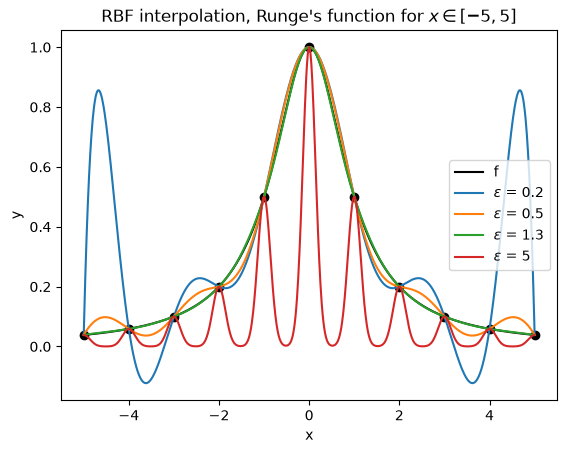

In [18]:
# Runge's function parameters
a = -5; b = 5; n = 10

def f(x):
    return 1 / (1 + x**2)

eps_vals_f = [0.2, 0.5, 1.3, 5]
plot_rbf(f, a, b, n, eps_vals_f, r"RBF interpolation, Runge's function for $ x \in [-5, 5]$")

I found that a suitable epsilon value can be $\epsilon \approx 1.3$, which checks out with the figure above.

Then I'll do the same interpolation on function nr. 1 from 1b), finding it suitable for $\epsilon \approx 1.4$, which checks out with the figure below.

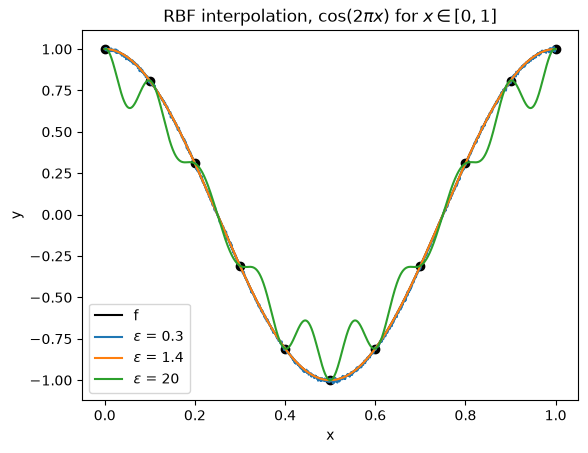

In [19]:
# test function parameters
a = 0; b = 1; n = 10

# one of the test functions from 1b)
def g(x):
    return np.cos(2*np.pi*x)

eps_vals_g = [0.3, 1.4, 20]
plot_rbf(g, a, b, n, eps_vals_g, r"RBF interpolation, $\cos(2\pi x)$ for $x \in [0,1]$")

Then I find the condition number together with the max norm error for the matrix $M$ for different epsilon values. I chose the max norm to ensure the error is never greater, ignoring numerical noise, which can be useful when considering how bad the interpolation can be. 

The error minima: eps = 1.41


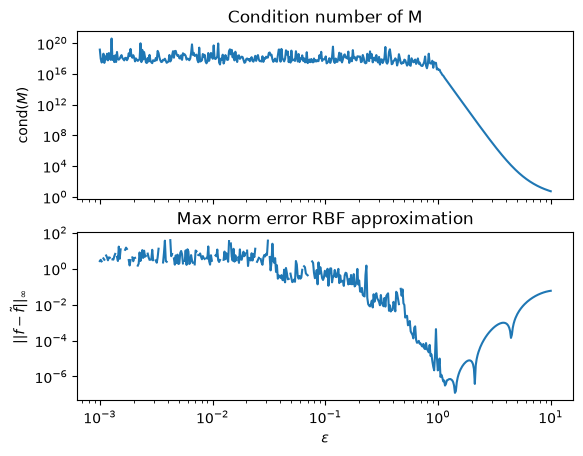

In [20]:
def cond_and_error(func, a, b, n, eps_vals):
    """cond(M) and max norm error for RBF interpolation of func, for every eps."""
    nodes = np.linspace(a, b, n+1)
    y_vals = func(nodes)
    x_eval = np.linspace(a, b, 100*(n+1))

    conds, errors = [], []
    for eps in eps_vals:
        M_eps = M(nodes, eps)
        conds.append(np.linalg.cond(M_eps))
        try:
            w = np.linalg.solve(M_eps, y_vals)
            errors.append(max_norm_error(func, x_eval, f_thilde(w, nodes, eps, x_eval)))
        except np.linalg.LinAlgError:
            errors.append(np.nan) # system not invertible
    return np.array(conds), np.array(errors)


eps_vals = np.logspace(-3, 1, num = 500)
M_cond, max_error = cond_and_error(g, a, b, n, eps_vals)

eps_min_index = np.nanargmin(max_error)
print(f"The error minima: eps = {eps_vals[eps_min_index]:.2f}")

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.loglog(eps_vals, M_cond)
ax1.set_title("Condition number of M")
ax1.set_ylabel(r"cond($M$)")

ax2.loglog(eps_vals, max_error)
ax2.set_title(r"Max norm error RBF approximation")
ax2.set_xlabel(r"$\epsilon$")
ax2.set_ylabel(r"$||f - \tilde{f}||_{\infty}$")

plt.show()

One can see in the figure above that the condition number of $M$ is large for $0 < \epsilon < 1$, which can be explained by the fact that the matrix $M$ is close to being singular: since $M_{ij} = e^{-(\epsilon r_{ij})^2} \approx 1 - (\epsilon r_{ij})^2$, all entries tend to $1$ as $\epsilon \to 0$. In floating point arithmetic the entries are rounded to exactly $1$ as soon as $(\epsilon r_{ij})^2$ falls below machine precision, and $M$ becomes numerically singular (one can in the plot of the max norm error for RBF interpolation see missing values for small epsilon, because the system could not be solved). The reason the condition number is more or less the same for small epsilon is that the smallest singular value is at level with the rounding error, so $\mathrm{cond}(M)$ oscillates around $10^{18}$ instead of following the true condition number, which keeps growing as $\epsilon \to 0$.

The max norm error for the RBF interpolant shows that the minimum of the error occurs for $\epsilon \approx 1.42$, and one reaches an "acceptable" max norm error $\lesssim 10^{-4}$ for $\epsilon \in [0.55, 4.5]$. The error is similarly noisy for $0 < \epsilon < 1$ as with the condition number. For large $\epsilon$ the system is well conditioned, but the error grows again due to the fact that the basis functions are too localized.

### Task 1e)

Firstly I'll create the functions I need for optimization of the equidistant nodes that we use to interpolate a given function, by using gradient descent with backtracking.

I've set some of parameters as the following:
$\rho = 0.5$, $\bar\rho = 1.5$, $\text{TOL} = 10^{-7}$ and $\text{max\_epochs} = 2000$.

In [21]:
import autograd.numpy as np
from autograd import value_and_grad
import matplotlib.pyplot as plt

# Runge's function
def f(x):
    return 1 / (1 + x**2)

def two_norm_error_square(f, x_eval, y_vals):
    """Discrete L2 error squared between f and the approximation y_vals sampled on nodes."""
    a, b = x_eval[0], x_eval[-1]
    N = len(x_eval)

    return (b - a)/N * np.sum((f(x_eval) - y_vals)**2)

# task parameters
a = -5; b = 5; N = 1000

# making a constructor for the loss function, 
# since we only want to optimize the function on nodes and theta
def make_loss(f, a, b, N):
    x_eval = np.linspace(a, b, N+1)
    f_eval = f(x_eval)

    def loss_fn(nodes, theta):
        eps = np.exp(theta)
        f_tilde = RBF_interpolate(nodes, f(nodes), x_eval, eps)
        return (b - a) / N * np.sum((f_eval - f_tilde)**2)

    return loss_fn, x_eval

loss_fn, x_eval = make_loss(f, a, b, N)
loss_and_grad = value_and_grad(loss_fn, (0, 1))


def pack(v, t):
    """Merges an array with a scalar."""
    return np.concatenate([v, np.atleast_1d(t)])


def clamp(x, a, b):
    """The nodes are clamped in the interval [a,b]."""
    return pack(np.clip(x[:-1], a, b), x[-1])


def optimal_nodes(a, b, n, eps0, L):
    rho = 0.5; rho_bar = 1.5; TOL = 1e-7; theta = np.log(eps0); max_epochs = 2000

    nodes = np.linspace(a, b, n+1)
    loss_history = []
    epoch = 0

    while epoch < max_epochs:
        nodes_prev = nodes.copy()
        theta_prev = theta

        loss, (grad_x, grad_theta) = loss_and_grad(nodes_prev, theta_prev)
        grad = pack(grad_x, grad_theta)
        x = pack(nodes_prev, theta_prev)

        if np.isnan(grad).any():
            print("Gradient has atleast one NaN-element")
            break

        if np.linalg.norm(grad) <= TOL:
            break

        max_inner_its = 100
        inner_it = 0

        # backtracking for gradient descent
        while inner_it < max_inner_its:
            x_thilde = clamp(x - (1/L) * grad, a, b) # make sure nodes are in [a,b]
            loss_thilde = loss_fn(x_thilde[:-1], x_thilde[-1])

            if loss_thilde <= loss + np.dot(grad, x_thilde - x) + L/2 * np.linalg.norm(x_thilde - x)**2:
                break

            L *= rho_bar
            inner_it += 1

        nodes = x_thilde[:-1]
        theta = x_thilde[-1]
        L *= rho

        # print(f"L = {L}") # debugging
        loss_history.append(loss)
        epoch += 1

        # check convergence
        if L * np.linalg.norm(x_thilde - x) <= TOL:
            break

    final_loss = loss_fn(nodes, theta)

    return pack(np.sort(nodes), np.exp(theta)), pack(loss_history, final_loss)

I avoid getting NaN in the gradient by using autodiff on $\phi(r_{sq}) = e^{-\epsilon^2 r_{sq}}$, where $r_{sq} = r^2$ in the RBF matrix, instead of the absolute value alternative.

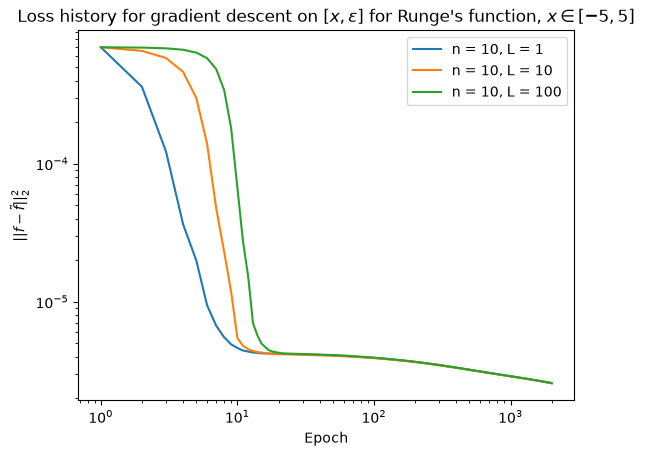

In [22]:
a = -5; b = 5; n = 10; eps0 = 1.4;

# finding optimal nodes for multiple startvalues of L
fig, ax = plt.subplots(1, 1)

L_vals = [1, 10, 100]

for i in range(len(L_vals)):
    params, loss_history = optimal_nodes(a, b, n, eps0, L_vals[i]) 
    epochs = np.arange(1, len(loss_history) + 1)

    ax.loglog(epochs, loss_history, label=f"n = {n}, L = {L_vals[i]}")

ax.set_title(r"Loss history for gradient descent on $[x,\epsilon]$ for Runge's function, $x\in [-5,5]$")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$||f - \tilde{f}||_{2}^2$")
ax.legend()

plt.show()

In the figure above we see the loss history for different start values of $L$. For low values $L$, the learing rate becomes large, meaning large steps are taken with gradient descent. For such low values like $L=1$ we see that the interpolant converges faster, but every value of $L$ reaches after some iterations. Additionally, one can observe that the chosen equidistant nodes are not far from optimal, since the loss is small, $\sim 10^{-3}$, which indicates that the initial parameters were already good. However, the loss continues to decrease.

   n      Optimal  Equidistant    Chebyshev
  10     2.58e-06     3.37e+00     3.23e-02
  15     6.41e-07     2.54e+00     5.47e-03
  20     9.77e-08     1.42e+03     5.63e-04
  25     6.09e-08     1.78e+03     1.02e-04
  30     2.01e-08     1.41e+06     1.06e-05
  35     4.07e-09     2.11e+06     1.92e-06
  40     1.12e-10     1.94e+09     1.98e-07
  45     5.19e-11     3.17e+09     3.60e-08
  50     8.05e-10     3.18e+12     3.73e-09


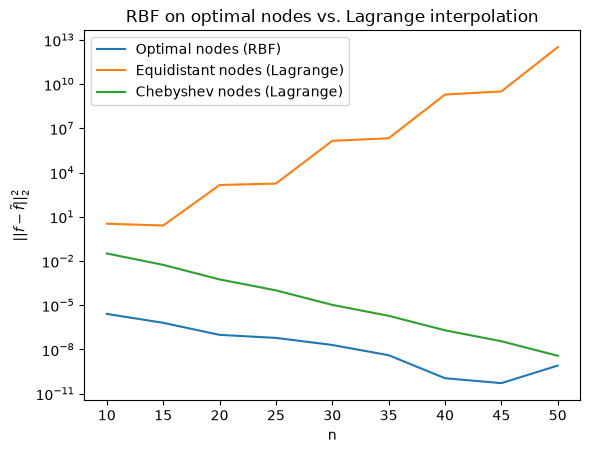

In [23]:
n_vals = np.arange(10, 51, 5)
N = len(x_eval) # points of evaluation

optimal_nodes_error = []
error_equidistant = []
error_chebyshev = []

optimal_params = []

for n in n_vals:
    # approximate 2 norm error for optimal nodes
    params, loss_history = optimal_nodes(a, b, n, eps0, L=100)

    optimal_params.append(params)
    optimal_nodes_error.append(loss_history[-1])

    e_nodes = np.linspace(a, b, n+1)
    c_nodes = chebyshev_nodes(a, b, n+1)

    eps = params[-1]

    error_equidistant.append(two_norm_error_square(f, x_eval, lagrange_error(f, n, a, b, N, chebyshev=False)[1]))
    error_chebyshev.append(two_norm_error_square(f, x_eval, lagrange_error(f, n, a, b, N, chebyshev=True)[1]))

# table with squared 2-norm [AI help]
print(f"{'n':>4} {'Optimal':>12} {'Equidistant':>12} {'Chebyshev':>12}")
for n, e_opt, e_eq, e_ch in zip(n_vals, optimal_nodes_error, error_equidistant, error_chebyshev):
    print(f"{n:>4} {e_opt:>12.2e} {e_eq:>12.2e} {e_ch:>12.2e}")

fig, ax = plt.subplots(1, 1)

ax.semilogy(n_vals, optimal_nodes_error, label="Optimal nodes (RBF)")
ax.semilogy(n_vals, error_equidistant, label="Equidistant nodes (Lagrange)")
ax.semilogy(n_vals, error_chebyshev, label="Chebyshev nodes (Lagrange)")

ax.set_title("RBF on optimal nodes vs. Lagrange interpolation")
ax.set_xlabel("n")
ax.set_ylabel(r"$||f - \tilde{f}||_{2}^2$")
ax.legend()

plt.show()

In the figure above one can observe that for the RBF interpolation the optimal nodes converges to the equidistant nodes, meaning that the optimal nodes are more or less equidistant for increasing $n$ here.

The interpolation error for Chebyshev and optimal nodes decreases for increasing values of $n$, and the interpolation error for equidistant nodes is steadily increasing, as seen previously for Runge's function.

For the largest values $n$ the interpolation error for optimal nodes increased a little. As seen previously in 1d), the explanation can be that the system is ill-conditioned:

In [24]:
for i in range(len(n_vals)):
    p = optimal_params[i]
    opt_nodes_last = p[:-1]
    eps_last = p[-1]

    print(f"Condition number for RBF matrix on the optimal nodes, n = {n_vals[i]}: {np.linalg.cond(M(opt_nodes_last, eps_last)):.3e}")

Condition number for RBF matrix on the optimal nodes, n = 10: 2.300e+00
Condition number for RBF matrix on the optimal nodes, n = 15: 1.109e+01
Condition number for RBF matrix on the optimal nodes, n = 20: 6.845e+01
Condition number for RBF matrix on the optimal nodes, n = 25: 1.378e+03
Condition number for RBF matrix on the optimal nodes, n = 30: 4.657e+04
Condition number for RBF matrix on the optimal nodes, n = 35: 1.580e+06
Condition number for RBF matrix on the optimal nodes, n = 40: 1.426e+08
Condition number for RBF matrix on the optimal nodes, n = 45: 2.234e+10
Condition number for RBF matrix on the optimal nodes, n = 50: 5.941e+12


We see that the system becomes more ill-conditioned for increasing $n$. Towards the end, the matrix is not far from singular, and the machine precision dominates the approximated error.

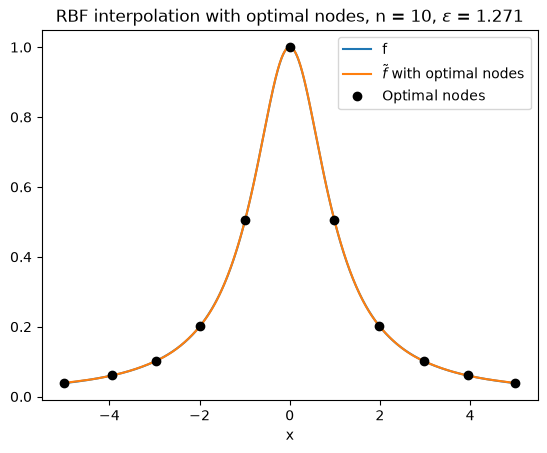

In [39]:
# compare tilde{f} with exact function for n = 10
nodes, eps = optimal_params[0][:-1], optimal_params[0][-1]
f_thilde_optimal = RBF_interpolate(nodes, f(nodes), x_eval, eps)

fig, ax = plt.subplots(1, 1)

ax.plot(x_eval, f(x_eval), label="f")
ax.plot(x_eval, f_thilde_optimal, label=r"$\tilde{f}$ with optimal nodes")
ax.plot(nodes, f(nodes), "o", label="Optimal nodes", color="black")

ax.set_title(rf"RBF interpolation with optimal nodes, n = {n_vals[0]}, $\epsilon$ = {eps:.3f}")
ax.set_xlabel("x")
ax.legend()

plt.show()

Here we see that the nodes are more or less equidistantly spread and disjoint, and the RBF interpolant interpolates the function well.

### Task 1f)

Let $\mathbf{x} = [x_0,\dots,x_n]$ be the nodes, and write $p_n(\eta;\mathbf{x})$ when we want to emphasise that the interpolation polynomial depends on the nodes. The cost function is

$$
C(\mathbf{x}) := \frac{b-a}{N}\sum_{k=0}^{N}\big(f(\eta_k)-p_n(\eta_k)\big)^2, \qquad p_n(\eta) = \sum_{i=0}^{n}\ell_i(\eta)\,f(x_i),
$$

so for $0 \le r \le n$

$$
\frac{\partial C}{\partial x_r}(\mathbf{x}) = -\frac{2(b-a)}{N}\sum_{k=0}^{N}\big(f(\eta_k)-p_n(\eta_k)\big)\,\frac{\partial p_n}{\partial x_r}(\eta_k).
$$

For the nodes $x_i$ it follows that $p_n(x_i) = f(x_i)$.

**Given $i \neq r$.** $x_r$ only enters $\ell_i(\eta) = \prod_{m\neq i}\frac{\eta-x_m}{x_i-x_m}$ through the factor with $m = r$, and

$$
\frac{\partial}{\partial x_r}\left(\frac{\eta-x_r}{x_i-x_r}\right) = \frac{(-1)(x_i-x_r)-(-1)(\eta-x_r)}{(x_i-x_r)^2} = \frac{\eta-x_i}{(x_i-x_r)^2},
$$

$$
\Longrightarrow\quad \frac{\partial \ell_i}{\partial x_r}(\eta) = \ell_i(\eta)\left(\frac{1}{x_i-x_r}-\frac{1}{\eta-x_r}\right).
$$

**Given $i = r$.** Let

$$
\ell_r(\eta) = \prod_{m\neq r}\frac{\eta-x_m}{x_r-x_m} = \frac{\prod_{m\neq r}(\eta-x_m)}{\prod_{m\neq r}(x_r-x_m)} =: \frac{g(\eta)}{h(x_r)}.
$$

By the quotient rule,

$$
\frac{\partial \ell_r}{\partial x_r} = \frac{0\cdot h(x_r)-g(\eta)\,h'(x_r)}{h(x_r)^2} = -\frac{g\,h'}{h^2}.
$$

Since

$$
\frac{h'}{h} = \frac{\partial}{\partial x_r}\log|h| = \frac{\partial}{\partial x_r}\sum_{m\neq r}\log|x_r-x_m| = \sum_{m\neq r}\frac{1}{x_r-x_m},
$$

we get

$$
\frac{\partial \ell_r}{\partial x_r}(\eta) = -\ell_r(\eta)\sum_{m\neq r}\frac{1}{x_r-x_m}.
$$

Applying the chain rule in two variables to the identity $p_n(x_r;\mathbf{x}) = f(x_r)$ gives

$$
\frac{d}{dx_r}\,p_n(x_r;\mathbf{x}) = \frac{\partial p_n}{\partial \eta}(x_r;\mathbf{x})\cdot\frac{\partial x_r}{\partial x_r} + \frac{\partial p_n}{\partial x_r}(x_r;\mathbf{x}),
$$

so, writing $p_n' = \partial p_n/\partial\eta$,

$$
f'(x_r) = p_n'(x_r) + \frac{\partial p_n}{\partial x_r}(x_r) \iff \frac{\partial p_n}{\partial x_r}(x_r) = f'(x_r)-p_n'(x_r).
$$

Now $\frac{\partial p_n}{\partial x_r}$ is a polynomial in $\eta$ of degree $\le n$, and $\frac{\partial p_n}{\partial x_r}(x_i) = 0$ for $i \neq r$ (since $p_n(x_i;\mathbf{x}) = f(x_i)$ does not depend on $x_r$). Hence we can write

$$
\frac{\partial p_n}{\partial x_r}(\eta) = \big(f'(x_r)-p_n'(x_r)\big)\,\ell_r(\eta),
$$

$$
\Longrightarrow\quad \frac{\partial C}{\partial x_r} = -\frac{2(b-a)}{N}\big(f'(x_r)-p_n'(x_r)\big)\sum_{k=0}^{N}\big(f(\eta_k)-p_n(\eta_k)\big)\,\ell_r(\eta_k).
$$

We can now find $\nabla C$, and get that

$$
\nabla C = 0 \iff \big(f'(x_r)-p_n'(x_r)\big)\sum_{k=0}^{N}\big(f(\eta_k)-p_n(\eta_k)\big)\,\ell_r(\eta_k) = 0, \qquad 0\le r\le n,
$$

which requires, for each $r$,

$$
f'(x_r) = p_n'(x_r) \quad\lor\quad \langle f-p_n,\ \ell_r\rangle_N = 0,
$$

where

$$
\langle g,h\rangle_N := \frac{b-a}{N}\sum_{k=0}^{N} g(\eta_k)\,h(\eta_k), \qquad \|g\|_N^2 := \langle g,g\rangle_N.
$$

I'll assume first that $f'(x_r) \neq p_n'(x_r)$. The functions $\ell_r$, $r = 0,\dots,n$, form a basis for $\mathcal{P}_n$, so if

$$
\langle f-p_n,\ \ell_r\rangle_N = \frac{b-a}{N}\sum_{k=0}^{N}\big(f(\eta_k)-p_n(\eta_k)\big)\,\ell_r(\eta_k) = 0
$$

for all $r$, then $f-p_n$ is orthogonal to all of $\mathcal{P}_n$.


Let $p \in \mathcal{P}_n$ with $f-p \perp \mathcal{P}_n$. Suppose $f-p$ changes sign on the grid only $m \le n$ times, namely in the intervals $(\eta_{k_j},\eta_{k_j+1})$, $j = 1,\dots,m$. Let

$$
q(\eta) = \alpha\prod_{j=1}^{m}(\eta-\beta_j), \qquad \alpha = \pm 1, \quad \beta_j \in (\eta_{k_j},\eta_{k_j+1}).
$$

Then $q \in \mathcal{P}_n$ changes sign exactly where $f-p$ does, so with the right choice of $\alpha$ we have $(f-p)(\eta_k)\,q(\eta_k) \ge 0$ for all $k$, with strict inequality for at least one $k$. This is a contradiction, since

$$
0 = \langle f-p,\ q\rangle_N = \frac{b-a}{N}\sum_{k=0}^{N}(f-p)(\eta_k)\,q(\eta_k) > 0.
$$

Hence $f-p$ changes sign in at least $n+1$ intervals. Since $f-p$ is continuous and $(f-p)(\eta_{k_j})\cdot(f-p)(\eta_{k_j+1}) < 0$ on $n+1$ disjoint intervals $(\eta_{k_j},\eta_{k_j+1})$, $f-p$ has $n+1$ distinct zeros in $(a,b)$.

Going back to $p_n$: for any $q \in \mathcal{P}_n$ we have $p_n - q \in \mathcal{P}_n$, so by orthogonality
 
$$
\|f-q\|_N^2 = \|(f-p_n)+(p_n-q)\|_N^2 = \|f-p_n\|_N^2 + \|p_n-q\|_N^2 \ge \|f-p_n\|_N^2,
$$
 
where there is an equality if $q = p_n$ (a polynomial of degree $\le n$ that is zero in all the $N+1 > n$ grid points must be $q = 0$).


Therefore we have $p_n = p^*$, where

$$
\|f-p^*\|_N^2 = \min_{q_n\in\mathcal{P}_n}\|f-q_n\|_N^2,
$$

so $p^*$ is the unique best approximation polynomial in the (discrete) $L^2$.


##### We can summarize the requirements for the optimal nodes with the following:

$\mathbf{x}$ is optimal if and only if the $x_r$ are distinct zeros of $f-p^*$:

(I) If all $x_r$ are zeros of $f-p^*$, then $p^*$ interpolates $f$ at the nodes. Uniqueness of the interpolation polynomial gives $p_n = p^*$, so $C(\mathbf{x}) = \|f-p^*\|_N^2$. This is minimal, since for any other nodes $\mathbf{x}'$ we have $p_n(\eta;\mathbf{x}') \in \mathcal{P}_n$ and therefore $C(\mathbf{x}') \ge \|f-p^*\|_N^2$.

(II) Assume $\mathbf{x}$ is optimal. By (I) the minimal value of $C$ is $\|f-p^*\|_N^2$ (such nodes exist, since $f-p^*$ has at least $n+1$ distinct zeros), and $p^*$ is unique, so $p_n = p^*$. It follows that $(f-p^*)(x_r) = 0$ for all $r$.

##### An alternative method for finding the optimal nodes

Choose an orthogonal basis $\{\varphi_0,\dots,\varphi_n\}$ for $\mathcal{P}_n$ (orthogonal with respect to $\langle\cdot,\cdot\rangle_N$) and write $p = \sum_{j} c_j\varphi_j$. Then we have shown that
 
$$
\langle f-p,\ \varphi_j\rangle_N = 0, \quad j = 0,\dots,n \iff \|f-p\|_N^2 = \min_{q\in\mathcal{P}_n}\|f-q\|_N^2 = \frac{b-a}{N}\min_{\mathbf{x}\in\mathbb{R}^{n+1}}\|A\mathbf{x}-\mathbf{b}\|_2^2, \qquad A_{kj} = \varphi_j(\eta_k), \quad b_k = f(\eta_k).
$$

The last equality holds because $(A\mathbf{x})_k = \sum_j x_j\varphi_j(\eta_k) = q(\eta_k)$, so $\|f-q\|_N^2 = \frac{b-a}{N}\|A\mathbf{x}-\mathbf{b}\|_2^2$ for every $\mathbf{x}$, not just at the minimum.

I recognize this as the least squares method, which gives
 
$$
A^TA\mathbf{x} = A^T\mathbf{b} \iff \langle f-p,\ \varphi_j\rangle_N = 0, \qquad j = 0,\dots,n.
$$
 
Where $(A^TA)_{ij} = \frac{N}{b-a}\langle \varphi_i,\varphi_j\rangle_N$, so $A^TA$ is the Gram matrix for the basis. Since our basis is orthogonal, $A^TA$ is diagonal and
 
$$
b_j = \frac{\langle f,\varphi_j\rangle_N}{\langle \varphi_j,\varphi_j\rangle_N}, \qquad j = 0,\dots,n.
$$
 
This system is therefore harder to solve with a non-orthogonal basis, but it is still possible.
